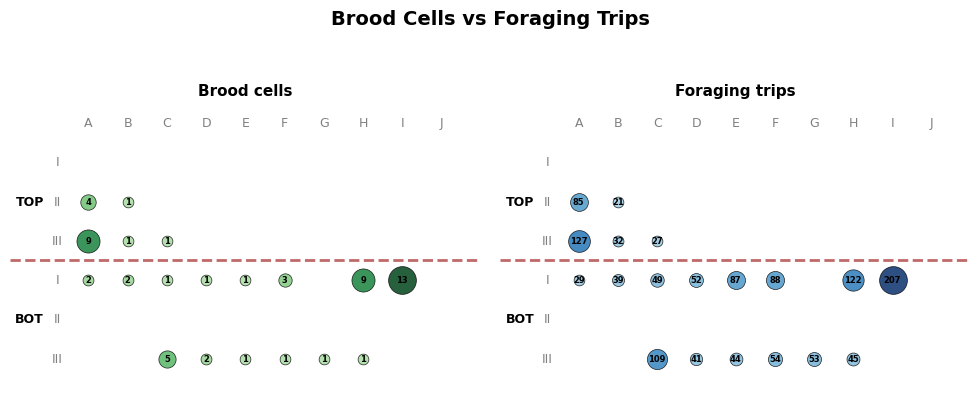

Release 1: 19 active tubes
Release 1: 59 total brood cells
Release 1: 1311 total foraging trips


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
raw = pd.read_csv("research_data/nesting_data.csv")
events = pd.read_csv("research_data/aggregated_events.csv")

# -----------------------------
# MAP NEST CODE -> TUBE NUMBER
# -----------------------------
frame_offset = {'MT': 0, 'NT': 0, 'MB': 30, 'NB': 30}
row_offset = {'I': 0, 'II': 10, 'III': 20}
letter_pos = {chr(65 + i): i + 1 for i in range(10)}

raw['row'] = raw['nest_code'].str.split('-').str[0]
raw['letter'] = raw['nest_code'].str.split('-').str[1]
raw['tube_num'] = raw.apply(
    lambda r: frame_offset.get(r['frame_id'], 0)
    + row_offset.get(r['row'], 0)
    + letter_pos.get(r['letter'], 0),
    axis=1
)

# -----------------------------
# FILTER TO MENDELS, RELEASE 1
# -----------------------------
raw_m = raw[raw['site'] == 'Mendels'].copy()
raw_r1 = raw_m[raw_m['release'] == 1].copy()

r1_tubes = np.sort(raw_r1['tube_num'].dropna().unique())

# brood cells per tube
r1_cells = raw_r1.groupby('tube_num').size()

# -----------------------------
# PREP EVENTS
# -----------------------------
events['event_datetime'] = pd.to_datetime(events['event_datetime'])
events_m = events[events['site'] == 'mendels'].copy()
events_m = events_m.sort_values(['nest', 'event_datetime'])

# -----------------------------
# BUILD TRIPS FROM EVENTS
# -----------------------------
trips = []

for nest, grp in events_m.groupby('nest'):
    grp = grp.sort_values('event_datetime').reset_index(drop=True)
    i = 0
    while i < len(grp) - 1:
        if grp.loc[i, 'action'] == 'Exit':
            for j in range(i + 1, len(grp)):
                if grp.loc[j, 'action'] == 'Entry':
                    exit_time = grp.loc[i, 'event_datetime']
                    entry_time = grp.loc[j, 'event_datetime']
                    duration = (entry_time - exit_time).total_seconds() / 60.0
                    trips.append({
                        'nest': nest,
                        'exit_time': exit_time,
                        'entry_time': entry_time,
                        'duration_min': duration
                    })
                    i = j + 1
                    break
            else:
                i += 1
        else:
            i += 1

trips_df = pd.DataFrame(trips)

# -----------------------------
# FILTER TO PLAUSIBLE TRIPS
# -----------------------------
trips_clean = trips_df[
    (trips_df['duration_min'] > 0.5) &
    (trips_df['duration_min'] < 30) &
    (trips_df['exit_time'].dt.hour.between(6, 20))
].copy()

# -----------------------------
# FILTER TO RELEASE 1 WINDOW
# -----------------------------
r1_trips = trips_clean[
    (trips_clean['exit_time'] >= '2024-04-16') &
    (trips_clean['exit_time'] < '2024-05-16')
].copy()

# trips per nest, only for release 1 tubes
r1_trip_counts = (
    r1_trips[r1_trips['nest'].isin(r1_tubes)]
    .groupby('nest')
    .size()
)

# -----------------------------
# PLOTTING HELPERS
# -----------------------------
def tube_to_grid(tube_num):
    grid_row = (tube_num - 1) // 10
    grid_col = (tube_num - 1) % 10
    return grid_row, grid_col

def draw_hotel(ax, tubes, counts, title, cmap_name='Greens'):
    max_val = counts.max() if len(counts) > 0 and counts.max() > 0 else 1
    cmap = plt.colormaps[cmap_name]

    for tube_num in tubes:
        grow, gcol = tube_to_grid(tube_num)
        y = 5 - grow
        val = counts.get(tube_num, 0)

        if val == 0:
            ax.scatter(
                gcol, y, s=60, c='#eeeeee',
                edgecolors='#cccccc', linewidths=0.5, zorder=2
            )
            continue

        norm_val = val / max_val
        size = max(norm_val * 400, 60)

        ax.scatter(
            gcol, y,
            s=size,
            c=[cmap(0.3 + norm_val * 0.7)],
            edgecolors='k',
            linewidths=0.5,
            alpha=0.85,
            zorder=2
        )
        ax.text(
            gcol, y, str(val),
            ha='center', va='center',
            fontsize=6, fontweight='bold', zorder=3
        )

    # divider between top and bottom frames
    ax.axhline(y=2.5, color='brown', linewidth=2, linestyle='--', alpha=0.7)

    for r, lbl in [(5, 'I'), (4, 'II'), (3, 'III'), (2, 'I'), (1, 'II'), (0, 'III')]:
        ax.text(-0.8, r, lbl, ha='center', va='center', fontsize=9, color='gray')

    for c in range(10):
        ax.text(c, 6.0, chr(65 + c), ha='center', va='center', fontsize=9, color='gray')

    ax.text(-1.5, 4.0, 'TOP', ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(-1.5, 1.0, 'BOT', ha='center', va='center', fontsize=9, fontweight='bold')

    ax.set_xlim(-2, 10)
    ax.set_ylim(-0.7, 6.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')

# -----------------------------
# FIGURE: RELEASE 1 ONLY
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Brood Cells vs Foraging Trips', fontsize=14, fontweight='bold')

draw_hotel(
    axes[0],
    r1_tubes,
    r1_cells,
    'Brood cells',
    'Greens'
)

draw_hotel(
    axes[1],
    r1_tubes,
    r1_trip_counts,
    'Foraging trips',
    'Blues'
)

plt.tight_layout()
#plt.savefig('mendels_release1_cells_vs_trips.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Release 1: {len(r1_tubes)} active tubes")
print(f"Release 1: {r1_cells.sum()} total brood cells")
print(f"Release 1: {r1_trip_counts.sum()} total foraging trips")

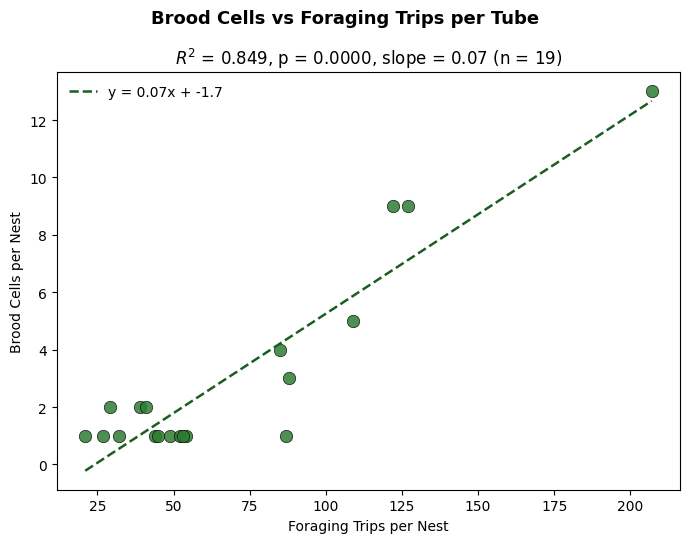

Release 1 (n = 19):
  slope = 0.069 cells/trip (±0.007)
  intercept = -1.68
  R² = 0.849
  p = 0.0000


In [20]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def build_compare(tubes, cells, trips):
    tubes_sorted = sorted(tubes)
    return pd.DataFrame({
        'tube': tubes_sorted,
        'cells': [cells.get(t, 0) for t in tubes_sorted],
        'trips': [trips.get(t, 0) for t in tubes_sorted]
    })

# Release 1 only
r1_df = build_compare(r1_tubes, r1_cells, r1_trip_counts)

# Linear regression
slope, intercept, r_val, p_val, std_err = stats.linregress(
    r1_df['trips'], r1_df['cells']
)

# Line for plotting
x_line = np.linspace(r1_df['trips'].min(), r1_df['trips'].max(), 100)
y_line = slope * x_line + intercept

# Plot
fig, ax = plt.subplots(figsize=(7, 5.5))
fig.suptitle(
    'Brood Cells vs Foraging Trips per Tube',
    fontsize=13,
    fontweight='bold'
)

# Scatter (clean)
ax.scatter(
    r1_df['trips'],
    r1_df['cells'],
    s=80,
    c='#2E7D32',
    edgecolors='k',
    linewidths=0.5,
    alpha=0.85
)

# Regression line
ax.plot(
    x_line,
    y_line,
    '--',
    color='#1B5E20',
    linewidth=1.8,
    label=f'y = {slope:.2f}x + {intercept:.1f}'
)

# Labels
ax.set_xlabel('Foraging Trips per Nest')
ax.set_ylabel('Brood Cells per Nest')

# Metrics in title (clean and reviewer-friendly)
ax.set_title(
    f'$R^2$ = {r_val**2:.3f}, p = {p_val:.4f}, slope = {slope:.2f} (n = {len(r1_df)})'
)

ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig('mendels_release1_linear_regression_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print(f"Release 1 (n = {len(r1_df)}):")
print(f"  slope = {slope:.3f} cells/trip (±{std_err:.3f})")
print(f"  intercept = {intercept:.2f}")
print(f"  R² = {r_val**2:.3f}")
print(f"  p = {p_val:.4f}")

Monitoring window: 2024-04-17 to 2024-05-15
Total trips (filtered): 1829
Unique nests: 60
5-min intervals: 4,859
Active: 825 (17.0%)
  Fold 1: AUC = 0.710
  Fold 2: AUC = 0.790
  Fold 3: AUC = 0.868
  Fold 4: AUC = 0.864
  Fold 5: AUC = 0.866

Mean AUC: 0.820 ± 0.062


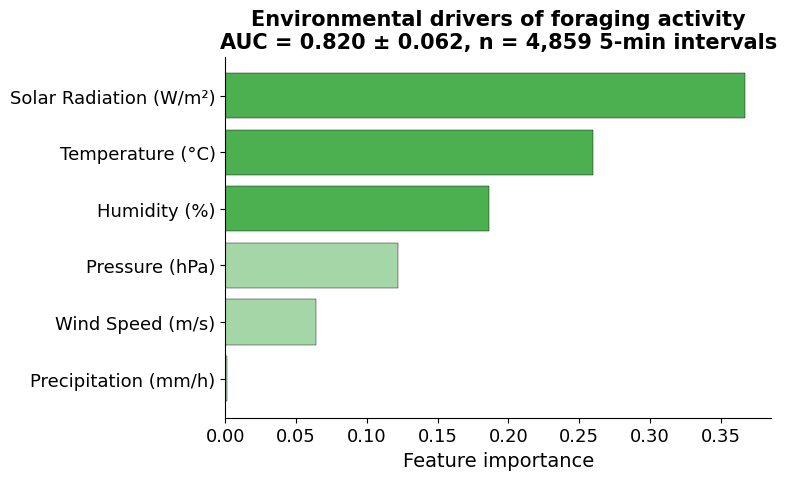

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ── Monitoring window ─────────────────────────────────────────────────────
# start_date = pd.Timestamp("2024-04-16")
# end_date   = pd.Timestamp("2024-05-15 23:59:59")

start_date = pd.Timestamp("2024-04-17")
end_date   = pd.Timestamp("2024-05-15")

# ── Load weather ──────────────────────────────────────────────────────────
weather = pd.read_csv('research_data/weather_5min.csv', parse_dates=['datetime'], index_col='datetime')
weather = weather.drop(columns=['wind_dir', 'uv'], errors='ignore')
weather.index = weather.index.floor('5min')
weather = weather.groupby(level=0).mean(numeric_only=True)
weather = weather[(weather.index >= start_date) & (weather.index <= end_date)].copy()

# ── Load foraging trips ───────────────────────────────────────────────────
trips = pd.read_csv('research_data/foraging_trips.csv', parse_dates=['exit_time'])
trips = trips[
    (trips['exit_time'] >= start_date) &
    (trips['exit_time'] <= end_date) &
    (trips['duration_min'] > 0.5) &
    (trips['duration_min'] < 30)
].copy()

print(f"Monitoring window: {start_date.date()} to {end_date.date()}")
print(f"Total trips (filtered): {len(trips)}")
print(f"Unique nests: {trips['nest'].nunique()}")

trips['time_bin'] = trips['exit_time'].dt.floor('5min')
trip_counts = trips.groupby('time_bin').size().rename('trips')

# ── Merge and aggregate ───────────────────────────────────────────────────
merged = weather.join(trip_counts, how='left')
merged['trips']  = merged['trips'].fillna(0).astype(int)
merged = merged[(merged.index.hour >= 6) & (merged.index.hour <= 20)].copy()
merged['active'] = (merged['trips'] > 0).astype(int)

# ── Features ──────────────────────────────────────────────────────────────
features = ['temperature', 'humidity', 'speed', 'pressure', 'precip_rate', 'solar']

label_map = {
    'temperature':  'Temperature (°C)',
    'humidity':     'Humidity (%)',
    'speed':        'Wind Speed (m/s)',
    'pressure':     'Pressure (hPa)',
    'precip_rate':  'Precipitation (mm/h)',
    'solar':        'Solar Radiation (W/m²)'
}

df = merged[features + ['active']].dropna().copy()
X  = df[features]
y  = df['active']

print(f"5-min intervals: {len(df):,}")
print(f"Active: {y.sum():,} ({y.mean()*100:.1f}%)")

# ── Time-series CV ────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

all_y_true, all_y_prob = [], []
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    rf = RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = rf.predict_proba(X.iloc[test_idx])[:, 1]

    fold_auc = roc_auc_score(y.iloc[test_idx], y_prob)
    fold_aucs.append(fold_auc)
    all_y_true.extend(y.iloc[test_idx])
    all_y_prob.extend(y_prob)
    print(f"  Fold {fold+1}: AUC = {fold_auc:.3f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
print(f"\nMean AUC: {mean_auc:.3f} ± {std_auc:.3f}")

# ── Final model ───────────────────────────────────────────────────────────
rf_final = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_final.fit(X, y)

# ── Feature importance figure ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14
})

fig, ax = plt.subplots(figsize=(8, 5))

importances = pd.Series(rf_final.feature_importances_, index=features).sort_values()
labels = [label_map[f] for f in importances.index]
colors = ['#4CAF50' if v > importances.median() else '#A5D6A7' for v in importances.values]

ax.barh(labels, importances.values, color=colors, edgecolor='k', linewidth=0.3)
ax.set_xlabel('Feature importance')
ax.set_title(
    f'Environmental drivers of foraging activity\n'
    f'AUC = {mean_auc:.3f} ± {std_auc:.3f}, n = {len(df):,} 5-min intervals',
    fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('rf_feature_importance_release1_clean.png', dpi=300, bbox_inches='tight')
plt.show()

Monitoring window: 2024-04-17 to 2024-05-15
Total trips (filtered): 1829
Unique nests: 60
5-min intervals: 4,859
Active: 825 (17.0%)
  Fold 1: AUC = 0.710
  Fold 2: AUC = 0.790
  Fold 3: AUC = 0.868
  Fold 4: AUC = 0.864
  Fold 5: AUC = 0.866

Mean AUC: 0.820 ± 0.062

Feature importances (ranked):
  Solar Radiation (W/m²)         0.3671  (36.7%)
  Temperature (°C)               0.2596  (26.0%)
  Humidity (%)                   0.1865  (18.7%)
  Pressure (hPa)                 0.1219  (12.2%)
  Wind Speed (m/s)               0.0637  (6.4%)
  Precipitation (mm/h)           0.0012  (0.1%)

Shared y-axis range: [-0.004, 0.568]


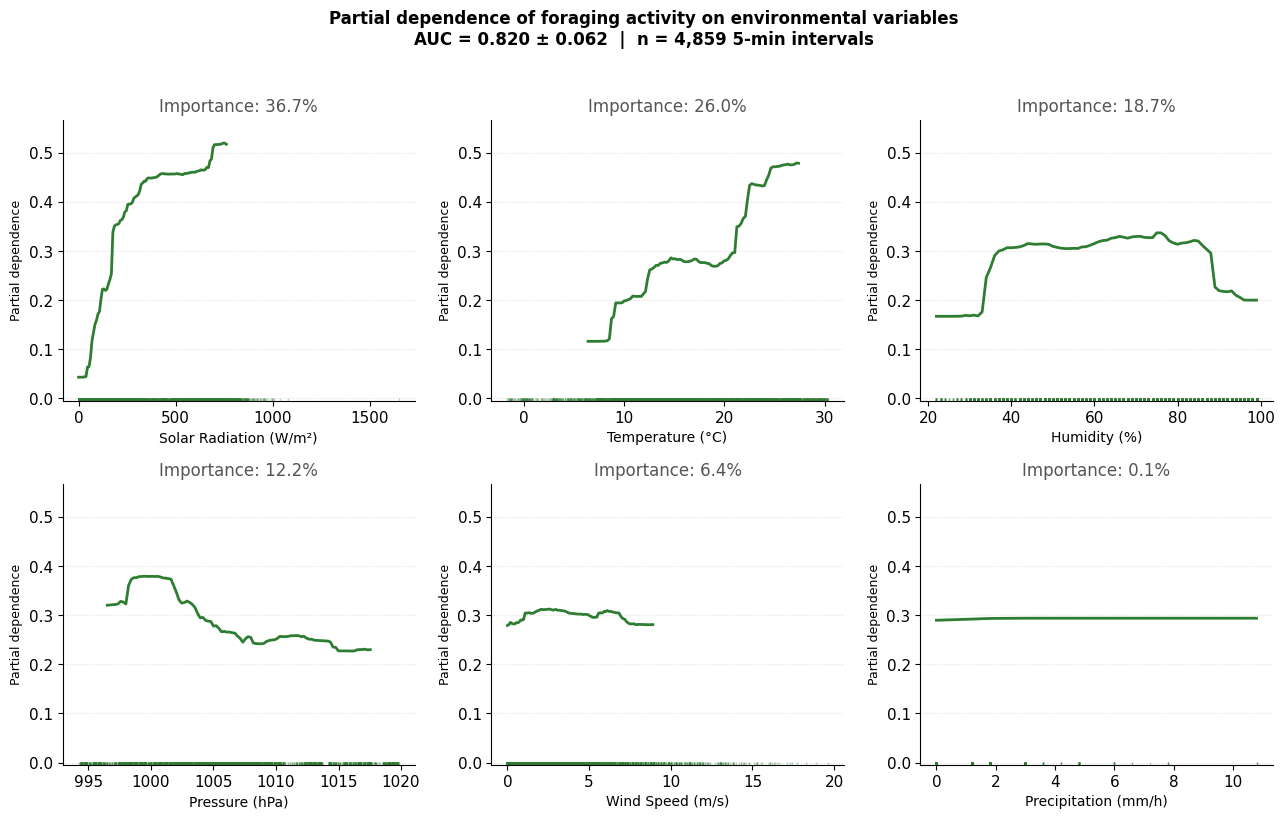


Saved: rf_partial_dependence_all


In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Monitoring window ─────────────────────────────────────────────────────
# start_date = pd.Timestamp("2024-04-16")
# end_date   = pd.Timestamp("2024-05-15 23:59:59")


start_date = pd.Timestamp("2024-04-17")
end_date   = pd.Timestamp("2024-05-15")

features  = ['temperature', 'humidity', 'speed', 'pressure', 'precip_rate', 'solar']
label_map = {
    'temperature':  'Temperature (°C)',
    'humidity':     'Humidity (%)',
    'speed':        'Wind Speed (m/s)',
    'pressure':     'Pressure (hPa)',
    'precip_rate':  'Precipitation (mm/h)',
    'solar':        'Solar Radiation (W/m²)'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size':   11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

# ── Load weather ──────────────────────────────────────────────────────────
weather = pd.read_csv('research_data/weather_5min.csv', parse_dates=['datetime'], index_col='datetime')
weather = weather.drop(columns=['wind_dir', 'uv'], errors='ignore')
weather.index = weather.index.floor('5min')
weather = weather.groupby(level=0).mean(numeric_only=True)
weather = weather[(weather.index >= start_date) & (weather.index <= end_date)].copy()

# ── Load foraging trips ───────────────────────────────────────────────────
trips = pd.read_csv('research_data/foraging_trips.csv', parse_dates=['exit_time'])
trips = trips[
    (trips['exit_time'] >= start_date) &
    (trips['exit_time'] <= end_date) &
    (trips['duration_min'] > 0.5) &
    (trips['duration_min'] < 30)
].copy()

print(f"Monitoring window: {start_date.date()} to {end_date.date()}")
print(f"Total trips (filtered): {len(trips)}")
print(f"Unique nests: {trips['nest'].nunique()}")

trips['time_bin'] = trips['exit_time'].dt.floor('5min')
trip_counts = trips.groupby('time_bin').size().rename('trips')

# ── Merge and aggregate ───────────────────────────────────────────────────
merged = weather.join(trip_counts, how='left')
merged['trips']  = merged['trips'].fillna(0).astype(int)
merged = merged[(merged.index.hour >= 6) & (merged.index.hour <= 20)].copy()
merged['active'] = (merged['trips'] > 0).astype(int)

df = merged[features + ['active']].dropna().copy()
X  = df[features]
y  = df['active']

print(f"5-min intervals: {len(df):,}")
print(f"Active: {y.sum():,} ({y.mean()*100:.1f}%)")

# ── Time-series CV ─────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    rf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=10,
                                class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = rf.predict_proba(X.iloc[test_idx])[:, 1]
    fold_aucs.append(roc_auc_score(y.iloc[test_idx], y_prob))
    print(f"  Fold {fold+1}: AUC = {fold_aucs[-1]:.3f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
print(f"\nMean AUC: {mean_auc:.3f} ± {std_auc:.3f}")

# ── Final model ────────────────────────────────────────────────────────────
rf_final = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=10,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X, y)

# ── Feature importance summary ─────────────────────────────────────────────
importances_sorted = pd.Series(rf_final.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances (ranked):")
for feat, imp in importances_sorted.items():
    print(f"  {label_map[feat]:<30} {imp:.4f}  ({imp*100:.1f}%)")

# ── Compute all PDP curves to get global y range ───────────────────────────
pdp_results = {}
all_pdp_values = []

for feat in features:
    feat_idx = features.index(feat)
    pdp = partial_dependence(rf_final, X, [feat_idx], kind='average')
    pdp_results[feat] = {
        'grid': pdp['grid_values'][0],
        'avg':  pdp['average'][0]
    }
    all_pdp_values.extend(pdp['average'][0].tolist())

y_min = min(all_pdp_values)
y_max = max(all_pdp_values)
y_pad = (y_max - y_min) * 0.1
y_lim = (y_min - y_pad, y_max + y_pad)
print(f"\nShared y-axis range: [{y_lim[0]:.3f}, {y_lim[1]:.3f}]")

# ── Plot with consistent y-axis ────────────────────────────────────────────
feat_order = importances_sorted.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, feat in zip(axes, feat_order):
    grid = pdp_results[feat]['grid']
    avg  = pdp_results[feat]['avg']

    ax.plot(grid, avg, color='#2E7D32', linewidth=2)

    feat_vals = X[feat].values
    ax.plot(feat_vals, np.full_like(feat_vals, y_lim[0]),
            '|', color='#2E7D32', alpha=0.3, markersize=4)

    importance_pct = importances_sorted[feat] * 100
    ax.set_xlabel(label_map[feat], fontsize=10)
    ax.set_ylabel('Partial dependence', fontsize=9)
    ax.set_title(f'Importance: {importance_pct:.1f}%', fontsize=12, color='#555555')
    ax.set_ylim(y_lim)
    ax.yaxis.grid(True, linestyle=':', alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle(
    f'Partial dependence of foraging activity on environmental variables\n'
    f'AUC = {mean_auc:.3f} ± {std_auc:.3f}  |  n = {len(df):,} 5-min intervals',
    fontweight='bold', fontsize=12, y=1.02
)

plt.tight_layout()
plt.savefig('rf_partial_dependence_all.png', dpi=300, bbox_inches='tight')
plt.savefig('rf_partial_dependence_all.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: rf_partial_dependence_all")

Device: cpu
Intervals: 4,859  Active: 964 (19.8%)

Running 5-fold time-series CV...
  Fold 1/5... Transformer AUC=0.762  RF AUC=0.718
  Fold 2/5... Transformer AUC=0.817  RF AUC=0.829
  Fold 3/5... Transformer AUC=0.827  RF AUC=0.850
  Fold 4/5... Transformer AUC=0.873  RF AUC=0.875
  Fold 5/5... Transformer AUC=0.892  RF AUC=0.871

Transformer  AUC: 0.834 ± 0.046
Random Forest    AUC: 0.829 ± 0.058
Improvement  : +0.6% AUC


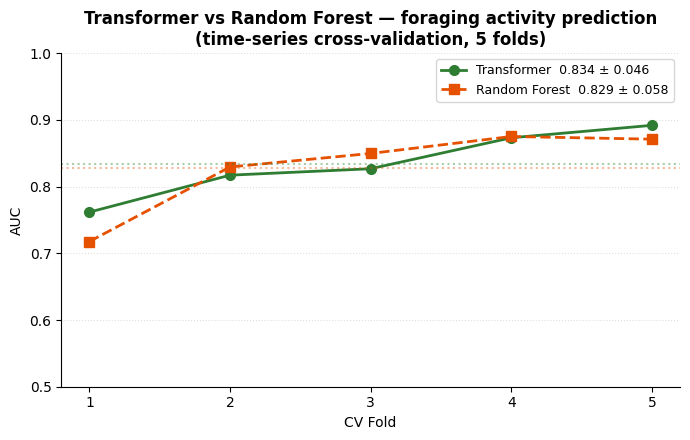


Saved: transformer_vs_rf


In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────
start_date = pd.Timestamp("2024-04-17")
end_date   = pd.Timestamp("2024-05-15")

features  = ['temperature', 'humidity', 'speed', 'pressure', 'precip_rate', 'solar']
label_map = {
    'temperature':  'Temperature (°C)',
    'humidity':     'Humidity (%)',
    'speed':        'Wind Speed (m/s)',
    'pressure':     'Pressure (hPa)',
    'precip_rate':  'Precipitation (mm/h)',
    'solar':        'Solar Radiation (W/m²)'
}

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS     = 80
BATCH_SIZE = 128
LR         = 1e-3
D_MODEL    = 64
N_HEADS    = 4
N_LAYERS   = 3
DROPOUT    = 0.1
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")

# ── Load & merge ───────────────────────────────────────────────────────────
weather = pd.read_csv('research_data/weather_5min.csv', parse_dates=['datetime'], index_col='datetime')
weather = weather.drop(columns=['wind_dir', 'uv'], errors='ignore')
weather.index = weather.index.floor('5min')
weather = weather.groupby(level=0).mean(numeric_only=True)
weather = weather[(weather.index >= start_date) & (weather.index <= end_date)].copy()

trips = pd.read_csv('research_data/foraging_trips.csv', parse_dates=['exit_time'])
trips = trips[(trips['exit_time'] >= start_date) & (trips['exit_time'] <= end_date)].copy()
trips['time_bin'] = trips['exit_time'].dt.floor('5min')
trip_counts = trips.groupby('time_bin').size().rename('trips')

merged = weather.join(trip_counts, how='left')
merged['trips']  = merged['trips'].fillna(0).astype(int)
merged = merged[(merged.index.hour >= 6) & (merged.index.hour <= 20)].copy()
merged['active'] = (merged['trips'] > 0).astype(int)

df = merged[features + ['active']].dropna().copy()
X  = df[features].values
y  = df['active'].values.astype(np.float32)

print(f"Intervals: {len(df):,}  Active: {y.sum():.0f} ({y.mean()*100:.1f}%)")

# ── Dataset ────────────────────────────────────────────────────────────────
class ForagingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── Model ──────────────────────────────────────────────────────────────────
class FeatureEmbedding(nn.Module):
    def __init__(self, n_features, d_model):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(n_features)
        ])

    def forward(self, x):
        tokens = [emb(x[:, i:i+1]) for i, emb in enumerate(self.embeddings)]
        return torch.stack(tokens, dim=1)  # (B, n_features, d_model)


class BinaryTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.embedding = FeatureEmbedding(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls_token, std=0.02)

        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        tokens = self.embedding(x)
        cls    = self.cls_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        out    = self.transformer(tokens)
        return self.head(out[:, 0, :]).squeeze(-1)


# ── Training ───────────────────────────────────────────────────────────────
def train_model(X_train, y_train, X_val, y_val):
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)

    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_dl = DataLoader(ForagingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(ForagingDataset(X_val,   y_val),   batch_size=BATCH_SIZE)

    model     = BinaryTransformer(len(features), D_MODEL, N_HEADS, N_LAYERS, DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_auc, best_state = 0, None

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            probs, trues = [], []
            with torch.no_grad():
                for xb, yb in val_dl:
                    probs.extend(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
                    trues.extend(yb.numpy())
            auc = roc_auc_score(trues, probs)
            if auc > best_auc:
                best_auc  = auc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, scaler


# ── Time-series CV ─────────────────────────────────────────────────────────
print("\nRunning 5-fold time-series CV...")
tscv = TimeSeriesSplit(n_splits=5)

tf_aucs, rf_aucs = [], []
all_y_true, all_tf_probs, all_rf_probs = [], [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"  Fold {fold+1}/5...", end=' ', flush=True)

    # Transformer
    model, scaler = train_model(X[train_idx], y[train_idx], X[test_idx], y[test_idx])
    model.eval()
    X_test_s = scaler.transform(X[test_idx])
    test_dl  = DataLoader(ForagingDataset(X_test_s, y[test_idx]), batch_size=BATCH_SIZE)
    tf_probs, trues = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            tf_probs.extend(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
            trues.extend(yb.numpy())
    tf_auc = roc_auc_score(trues, tf_probs)
    tf_aucs.append(tf_auc)

    # RF baseline
    rf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=10,
                                class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf.fit(X[train_idx], y[train_idx])
    rf_probs = rf.predict_proba(X[test_idx])[:, 1]
    rf_auc   = roc_auc_score(y[test_idx], rf_probs)
    rf_aucs.append(rf_auc)

    all_y_true.extend(trues)
    all_tf_probs.extend(tf_probs)
    all_rf_probs.extend(rf_probs)

    print(f"Transformer AUC={tf_auc:.3f}  RF AUC={rf_auc:.3f}")

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Transformer  AUC: {np.mean(tf_aucs):.3f} ± {np.std(tf_aucs):.3f}")
print(f"Random Forest    AUC: {np.mean(rf_aucs):.3f} ± {np.std(rf_aucs):.3f}")
print(f"Improvement  : {(np.mean(tf_aucs) - np.mean(rf_aucs))*100:+.1f}% AUC")
print(f"{'='*50}")

# ── Figure ─────────────────────────────────────────────────────────────────
plt.rcParams.update({'font.family':'sans-serif','font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(1, 6)
ax.plot(x, tf_aucs, 'o-', color='#2E7D32', linewidth=2,
        label=f'Transformer  {np.mean(tf_aucs):.3f} ± {np.std(tf_aucs):.3f}', markersize=7)
ax.plot(x, rf_aucs, 's--', color='#E65100', linewidth=2,
        label=f'Random Forest  {np.mean(rf_aucs):.3f} ± {np.std(rf_aucs):.3f}', markersize=7)

ax.axhline(np.mean(tf_aucs), color='#2E7D32', linestyle=':', alpha=0.4)
ax.axhline(np.mean(rf_aucs), color='#E65100', linestyle=':', alpha=0.4)

ax.set_xlabel('CV Fold')
ax.set_ylabel('AUC')
ax.set_xticks(x)
ax.set_ylim(0.5, 1.0)
ax.set_title('Transformer vs Random Forest — foraging activity prediction\n'
             '(time-series cross-validation, 5 folds)', fontweight='bold')
ax.legend(fontsize=9, frameon=True, edgecolor='#cccccc')
ax.yaxis.grid(True, linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig('transformer_vs_rf.png', dpi=300, bbox_inches='tight')
# plt.savefig('transformer_vs_rf.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: transformer_vs_rf")